#### Purpose of the Code
This program performs unsupervised clustering on real penguin measurement data (culmen length and depth).
It:

- Loads and cleans the CSV dataset.
- Uses K-Means (or optionally Mean Shift) to group penguins into clusters based on their beak size (culmen length and depth).
- Displays the cluster centroids.
- Visualizes the clusters in a scatter plot with labeled cluster centers.

In [1]:
import numpy as np  # For numerical operations and arrays
import pandas as pd  # For reading and cleaning tabular data
import matplotlib.pyplot as plt  # For plotting
from matplotlib.colors import Normalize  # For consistent color scaling


In [2]:
# Import clustering algorithms from scikit-learn
from sklearn.cluster import KMeans, MeanShift


In [3]:
# Read the penguin dataset (make sure the file path is correct)
df = pd.read_csv('penguins_data.csv')
print(df.head(), '\n')


  species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen              39.1             18.7              181.0   
1  Adelie  Torgersen              39.5             17.4              186.0   
2  Adelie  Torgersen              40.3             18.0              195.0   
3  Adelie  Torgersen               NaN              NaN                NaN   
4  Adelie  Torgersen              36.7             19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE   



In [4]:
# Drop rows containing missing (NaN) values in any column
df = df.dropna(axis=0)
print(df.head(), '\n')

  species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen              39.1             18.7              181.0   
1  Adelie  Torgersen              39.5             17.4              186.0   
2  Adelie  Torgersen              40.3             18.0              195.0   
4  Adelie  Torgersen              36.7             19.3              193.0   
5  Adelie  Torgersen              39.3             20.6              190.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
4       3450.0  FEMALE  
5       3650.0    MALE   



In [5]:
# Select the columns for clustering — here columns 2 and 3 (culmen_length_mm and culmen_depth_mm)
X = df.iloc[:, [2, 3]].values


In [10]:
# Construct the clustering model
model = KMeans(n_clusters=4, n_init='auto', random_state=5)
# model = MeanShift()  # Alternative algorithm (auto-detects number of clusters)

# Fit (train) the model using the selected features
model.fit(X)


kmeans = KMeans(n_clusters=4, n_init='auto', random_state=5)
# model = MeanShift()
kmeans.fit(X)

KMeans(n_clusters=4, random_state=5)

In [12]:
# Extract the cluster centroids from the fitted model
cluster_centers = model.cluster_centers_
centers = model.cluster_centers_
print('Centroids:', centers, '\n')


# Define a new data point for testing
test_point = np.array([[3, 1]])

centers_k = kmeans.cluster_centers_
print('Prediction:', kmeans.predict(test_point), '\n')


Centroids: [[36.50882353 17.94117647]
 [51.09102564 17.51538462]
 [40.81686747 18.46385542]
 [46.08190476 15.36095238]] 

Prediction: [0] 



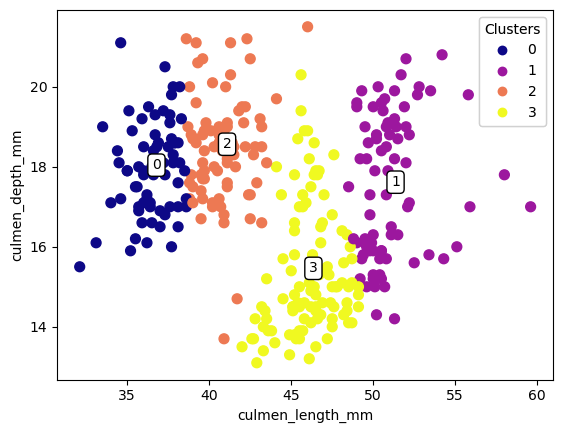

In [13]:
# Create a new plot
fig, ax = plt.subplots()

# Normalize colors so cluster colors map evenly to the plasma colormap
nm = Normalize(vmin=0, vmax=len(centers)-1)

# Scatter plot of the data points colored by their assigned cluster
scatter1 = ax.scatter(X[:, 0], X[:, 1],
                      c=model.predict(X), s=50, cmap='plasma', norm=nm)

# Plot each centroid and label it with its cluster index
for i in range(centers.shape[0]):
    ax.text(centers[i, 0], centers[i, 1], str(i), c='black',
            bbox=dict(boxstyle="round", facecolor='white', edgecolor='black'))

# Label the axes using the column names from the DataFrame
ax.set_xlabel(df.columns[2])
ax.set_ylabel(df.columns[3])

# Create a legend that shows which colors correspond to which clusters
legend1 = ax.legend(*scatter1.legend_elements(),
                    loc="upper right", title="Clusters")
ax.add_artist(legend1)



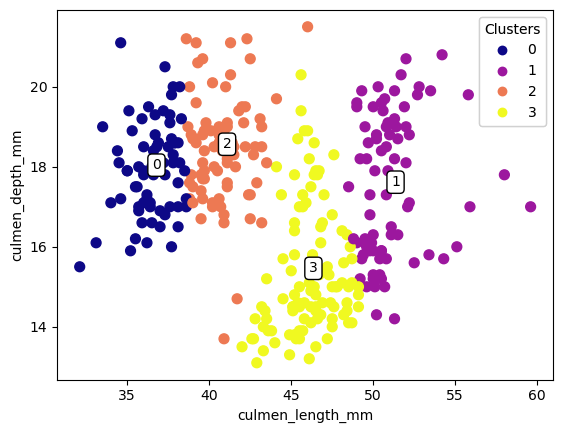

In [14]:
# Create a new plot
fig, ax = plt.subplots()

# Normalize colors so cluster colors map evenly to the plasma colormap
nm = Normalize(vmin=0, vmax=len(centers_k)-1)

# Scatter plot of the data points colored by their assigned cluster
scatter1 = ax.scatter(X[:, 0], X[:, 1],
                      c=kmeans.predict(X), s=50, cmap='plasma', norm=nm)

# Plot each centroid and label it with its cluster index
for i in range(centers_k.shape[0]):
    ax.text(centers_k[i, 0], centers_k[i, 1], str(i), c='black',
            bbox=dict(boxstyle="round", facecolor='white', edgecolor='black'))

# Label the axes using the column names from the DataFrame
ax.set_xlabel(df.columns[2])
ax.set_ylabel(df.columns[3])

# Create a legend that shows which colors correspond to which clusters
legend1 = ax.legend(*scatter1.legend_elements(),
                    loc="upper right", title="Clusters")
ax.add_artist(legend1)

